<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 52%, #2f7d73 100%);
    padding: 40px 36px 32px 36px;
    border-radius: 14px;
    margin: 8px 0 22px 0;
    box-shadow: 0 10px 28px rgba(16, 42, 67, 0.28);
    border: 1px solid rgba(255,255,255,0.16);
    text-align: center;
">
    <p style="color: rgba(255,255,255,0.72); margin: 0 0 10px 0; font-size: 12px; letter-spacing: 4px; text-transform: uppercase;">PHY-3202 · Notebook 02</p>
    <h1 style="color: white; margin: 0; font-size: 34px; font-weight: 400; letter-spacing: 1px;">Modèle de réseau, cascades, évolution et validation</h1>
    <div style="width: 72px; height: 3px; background: #e7a23b; margin: 18px auto 14px auto; border-radius: 3px;"></div>
    <p style="color: rgba(255,255,255,0.92); margin: 0; font-size: 17px;">Du DC power flow à la réplication contrôlée de Carreras</p>
</div>

<div style="
    background: #e8f0f2;
    color: #1f2933;
    border-left: 6px solid #1f4e5f;
    border-radius: 9px;
    padding: 16px 20px;
    margin: 0 0 18px 0;
">
<strong>Auteur :</strong> Alex Baker &nbsp; · &nbsp;
<strong>Superviseur :</strong> Patrick Desrosiers &nbsp; · &nbsp;
<strong>Idée original du projet :</strong> Nickie Menementis  &nbsp; · &nbsp; 
<strong>Référence principale :</strong> Carreras et al. (2002, 2004)
</div>

## Fil directeur

Ce notebook constitue le **fil A** du projet. Son rôle n'est pas encore de chercher un précurseur informationnel : il doit d'abord construire un générateur de données électriques que l'on comprend, que l'on peut tester et dont on connaît les limites.

Le chemin logique est

$$
\boxed{
\text{réseau}
\rightarrow
\text{DC power flow}
\rightarrow
\text{dispatch}
\rightarrow
\text{cascade}
\rightarrow
\text{évolution}
\rightarrow
\text{validation statistique}
\rightarrow
\text{séries temporelles}
}
$$

avant de passer au **fil B**, consacré aux entropies et aux mesures d'information.

<div style="background:#fff6e8;color:#1f2933;border-left:5px solid #e7a23b;padding:14px 18px;border-radius:8px;margin:16px 0;">
<strong>Mise à jour importante — 3 octobre 2026.</strong>
Une première version de ce notebook interprétait <code style="color: #1f2933; background: transparent;">P_G=2623.9</code> comme la capacité totale P_C et recalibrait les limites de lignes pour imposer une transition à P_D/P_C = 1.45. La relecture de Carreras et al. montre que P_G est la capacité <em>par générateur</em> et que P_C = somme_j P_j^max = 12 P_G. La présente version remplace donc cette calibration par les paramètres de la Table I et intègre la réplication contrôlée anciennement documentée dans un notebook séparé.
</div>

### Trois échelles à ne pas confondre

1. **Balayage paramétrique** : $P_D/P_C$ varie; l'axe horizontal n'est pas le temps.
2. **Cascade rapide** : plusieurs redispatchs successifs décrivent les étapes d'un même blackout.
3. **Évolution lente** : plusieurs journées sont reliées par la croissance et les réponses d'ingénierie.

La même variable « jour » peut donc désigner soit un simple numéro de réalisation Monte-Carlo, soit un vrai pas d'une dynamique avec mémoire. Toute la suite du projet dépend de cette distinction.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from cascade_entropy import evolution, figures
from cascade_entropy.carreras import (
    CAPACITES_TABLE,
    GAMMA_TABLE,
    P0_TABLE,
    P1_REFERENCE,
    P_G_TABLE,
    P_L_TABLE,
    configuration_arbre,
    demande_regionale,
    groupes_regions,
    sigma_relatif_papier,
    sigma_relatif_uniforme,
)
from cascade_entropy.cascade import journee
from cascade_entropy.chemins import DOSSIER_DATA, DOSSIER_FIGURES
from cascade_entropy.dispatch import demande_uniforme, resoudre
from cascade_entropy.entropie import entropie_repartition, nombre_effectif
from cascade_entropy.reseau import Reseau, matrice_de_flux

figures.appliquer_style()

GRAINE = 20260915
DATA_REP = DOSSIER_DATA / "05_reproduction_carreras"
FIG_REP = DOSSIER_FIGURES / "05_reproduction_carreras"

cfg46 = configuration_arbre(46)
reseau = cfg46.reseau
limites = cfg46.limites
p_max = cfg46.puissance_max
P_C = cfg46.p_c
A = matrice_de_flux(reseau)

print(f"Réseau de travail : {reseau.n_noeuds} nœuds, {reseau.n_lignes} lignes")
print(f"Générateurs       : {reseau.generateurs.size}")
print(f"P_G               : {P_G_TABLE:.1f} par générateur")
print(f"P_C = Σ P_G^max   : {P_C:.1f}")

Réseau de travail : 46 nœuds, 45 lignes
Générateurs       : 12
P_G               : 2623.9 par générateur
P_C = Σ P_G^max   : 31486.8


<div style="
    background: #0f3345;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #e7a23b;
">
    <p style="color: #a9cbd7; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie I</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Fondations mathématiques et état stationnaire</h2>
</div>


<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 01 · DC power flow</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Des injections nodales aux flux de ligne</h2>
</div>


Le modèle de Carreras repose sur l'approximation **DC power flow**. Elle ne décrit pas toute la physique électromagnétique d'un réseau AC; elle conserve la partie utile ici : le lien linéaire entre injections de puissance, angles de phase et flux actifs.

Pour une ligne $\ell=(i,j)$ de réactance $x_{ij}$, on écrit

$$F_{ij} = \frac{\theta_i-\theta_j}{x_{ij}} = b_{ij}(\theta_i-\theta_j), \qquad b_{ij}=\frac{1}{x_{ij}}$$

À chaque nœud, la conservation de la puissance impose

$$P_i=\sum_j F_{ij}$$

ce qui se regroupe sous forme matricielle :

$$\mathbf P = \mathbf B\,\boldsymbol\theta$$

La matrice $\mathbf B$ est singulière parce que seuls les **écarts** d'angle ont un sens. On fixe donc un nœud de référence, $\theta_{\rm ref}=0$, puis on résout le système réduit. Les flux s'obtiennent ensuite comme une transformation linéaire des injections :

$$\boxed{\mathbf F=\mathbf A\,\mathbf P_{\setminus \rm ref}}$$

`matrice_de_flux()` construit précisément cette matrice $\mathbf A$.

<div style="background:#eef7f4;color:#1f2933;border-left:4px solid #2f7d73;padding:12px 16px;border-radius:7px;">
<strong>Lecture simple.</strong> Les injections disent « où la puissance entre et sort ». Les angles sont l'état intermédiaire imposé par les équations du réseau, et les flux disent « par quelles lignes la puissance circule ». Sur un arbre, il n'existe qu'un chemin entre deux nœuds : le flux d'une branche est donc simplement la somme nette de ce qui doit être alimenté en aval.
</div>

<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 02 · Optimisation</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Le dispatch comme programme linéaire</h2>
</div>


Pour une demande $\mathbf d$, le dispatch choisit simultanément :

- la production $G_i$ de chaque générateur;
- la charge effectivement servie $L_j$ à chaque nœud de demande.

Dans le code, le problème est

$$\min_{\mathbf G,\mathbf L} \left[ \sum_i G_i-W\sum_j L_j \right], \qquad W=100$$

sous les contraintes

$$0\le G_i\le P_i^{\max}$$

$$0\le L_j\le d_j$$

$$\sum_iG_i=\sum_jL_j$$

et, pour chaque ligne $\ell$,

$$-F_\ell^{\max}\le F_\ell(\mathbf G,\mathbf L)\le F_\ell^{\max}$$

Comme l'équilibre impose $\sum_iG_i=\sum_jL_j$, l'objectif devient

$$(1-W)\sum_jL_j$$

Puisque $W>1$, **minimiser** cet objectif revient exactement à **maximiser la charge totale servie**. Le délestage

$$P_{\rm shed}=\sum_j(d_j-L_j)$$

est donc le minimum nécessaire pour rendre l'état compatible avec les contraintes.

Pour mesurer la sollicitation d'une ligne, on utilise

$$M_\ell=\frac{|F_\ell|}{F_\ell^{\max}}, \qquad M_{\max}=\max_\ell M_\ell$$

Une ligne est considérée candidate à la surcharge lorsque $M_\ell\ge0.99$.

<div style="background:#f8f4ea;color:#1f2933;border-left:4px solid #e7a23b;padding:12px 16px;border-radius:7px;">
<strong>Point essentiel.</strong> Le solveur n'autorise jamais M_l &gt; 1. Une ligne dite « surchargée » dans la cascade est donc une ligne collée à sa contrainte, pas une ligne qui transporte numériquement plus que sa limite.
</div>

In [2]:
chaine = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([10.0, 10.0]),
    reference=0,
)

solution = resoudre(
    chaine,
    demande=np.array([1.0, 1.0]),
    puissance_max=np.array([10.0]),
)

print("Chaîne 0—1—2, générateur en 0, deux charges d'une unité")
print(f"production      : {solution.production}")
print(f"charge servie   : {solution.charge_servie}")
print(f"flux            : {solution.flux}   (attendu [2, 1])")
print(f"délestage       : {solution.delestage_total}")

Chaîne 0—1—2, générateur en 0, deux charges d'une unité
production      : [2.]
charge servie   : [1. 1.]
flux            : [2. 1.]   (attendu [2, 1])
délestage       : 0.0


La ligne $1\!-\!2$ ne transporte que la charge du nœud 2 :

$$F_{12}=1$$

La ligne $0\!-\!1$ doit en plus alimenter le nœud 1 :

$$F_{01}=1+1=2$$

Le résultat numérique $[2,1]$ est donc vérifiable sans solveur. Cette cellule sert de **test local** : avant de faire confiance à un réseau de dizaines de nœuds, on vérifie une situation où aucune ambiguïté n'est possible.

In [3]:
chaine_limitee = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([1.5, 10.0]),
    reference=0,
)

limitee = resoudre(
    chaine_limitee,
    demande=np.array([1.0, 1.0]),
    puissance_max=np.array([10.0]),
)

print(f"flux            : {limitee.flux}")
print(f"charge servie   : {limitee.charge_servie}")
print(f"délestage       : {limitee.delestage_total}   (attendu 0,5)")
print(f"M_max           : {limitee.taux_maximal}")
print(f"lignes saturées : {limitee.lignes_saturees}")

flux            : [1.5 1. ]
charge servie   : [0.5 1. ]
délestage       : 0.5   (attendu 0,5)
M_max           : 1.0
lignes saturées : [0]


La ligne amont ne peut transporter que $1.5$. Comme la demande totale vaut 2, le solveur doit couper exactement

$$P_{\rm shed}=2-1.5=0.5$$

Son taux de charge vaut

$$M=\frac{1.5}{1.5}=1$$

Le délestage n'est donc pas un défaut numérique : c'est la variable qui permet au réseau de rester dans l'ensemble des états admissibles.

<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 03 · Observable spatiale</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Entropie de répartition et nombre effectif</h2>
</div>


$M_{max}$ décrit uniquement **la ligne la plus sollicitée**. Pour savoir si les flux sont répartis sur tout le réseau ou concentrés sur quelques branches, on construit une distribution spatiale

$$p_\ell = \frac{|F_\ell|}{\sum_m |F_m|}$$

Son entropie de Shannon est

$$H_F=-\sum_\ell p_\ell\ln p_\ell$$

On la transforme en un nombre effectif de lignes :

$$\boxed{N_{\rm eff}=e^{H_F}}$$

Cette écriture possède une interprétation directe :

$$1\le N_{\rm eff}\le N_{\rm lignes}$$

Si $K$ lignes portent exactement la même part de puissance et toutes les autres
sont nulles, alors $p_\ell=1/K$ sur ces lignes et

$$H_F=\ln K, \qquad N_{\rm eff}=K$$

<div style="background:#eef7f4;color:#1f2933;border-left:4px solid #2f7d73;padding:12px 16px;border-radius:7px;">
<strong>Lecture simple.</strong> M_max répond à « quelle est la pire ligne ? ». N_eff répond à « combien de lignes participent réellement au transport ? ». Ce sont deux informations différentes sur le même état.
</div>

<div style="
    background: #2f3d43;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #d6b26e;
">
    <p style="color: #d7e0e3; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie II</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Le réseau de Carreras avec les paramètres publiés</h2>
</div>


<div style="
    background: linear-gradient(135deg, #3f5360 0%, #607d8b 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #d6b26e;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #e2ecef; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 04 · Topologie autosimilaire</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Arbres de 46, 94, 190 et 382 nœuds</h2>
</div>


Carreras et al. utilisent des arbres artificiels pour pouvoir augmenter la taille du réseau sans changer sa structure fondamentale. Avec $n$ générations, le nombre de nœuds est

$$\boxed{N_N=3\,2^n-2}$$

Ainsi,

$$n=4,5,6,7 \quad\Longrightarrow\quad N_N=46,94,190,382$$

Les 12 générateurs restent au troisième niveau lorsque l'arbre grandit. Les nœuds ajoutés sont donc essentiellement de nouvelles charges en périphérie.

La Table I fournit un paramètre de générateur

$$P_G=2623.9$$

Le papier définit la capacité totale comme

$$P_C=\sum_{j\in G}P_j^{\max}$$

Avec 12 générateurs identiques dans notre reconstruction,

$$\boxed{P_C=12P_G = 12(2623.9) = 31486.8}$$

Les limites de transport utilisées, du centre vers la périphérie, sont

| niveau | $F^{\max}$ |
|---:|---:|
| 1 | 15620.0 |
| 2 | 7748.7 |
| 3 | 3812.9 |
| 4 | 1844.9 |
| 5 | 860.97 |
| 6 | 368.99 |
| 7 | 123.00 |

Le réseau de 46 nœuds utilise les quatre premières valeurs, celui de 94 les cinq premières, etc. **Aucun facteur de recalibration dépendant de la taille n'est désormais appliqué.**

<div style="background:#fff6e8;color:#1f2933;border-left:4px solid #d6b26e;padding:12px 16px;border-radius:7px;">
<strong>Pourquoi cette correction compte.</strong> Dans l'ancienne version, prendre 2623.9 pour P_C réduisait artificiellement la capacité totale d'un facteur 12. Recalibrer ensuite les lignes masquait en partie cette erreur. La version actuelle garde les paramètres du papier dans leurs rôles respectifs.
</div>

In [4]:
audit = []
for n_noeuds in (46, 94, 190, 382):
    cfg = configuration_arbre(n_noeuds)
    audit.append({
        "nœuds": n_noeuds,
        "lignes": cfg.reseau.n_lignes,
        "charges": cfg.n_charges,
        "générateurs": cfg.n_generateurs,
        "P_G par générateur": cfg.puissance_max[0],
        "P_C total": cfg.p_c,
        "P_D/P_C si P_L=-74": cfg.ratio_table,
        "niveaux de limites": np.unique(cfg.limites).size,
    })

display(pd.DataFrame(audit))

,nœuds,lignes,charges,générateurs,P_G par générateur,P_C total,P_D/P_C si P_L=-74,niveaux de limites
0,46,45,34,12,2623.9,31486.8,0.079907,4
1,94,93,82,12,2623.9,31486.8,0.192716,5
2,190,189,178,12,2623.9,31486.8,0.418334,6
3,382,381,370,12,2623.9,31486.8,0.869571,7


### Aperçu visuel du réseau

Avant de poursuivre avec les balayages, il est utile de visualiser le réseau en arbre. La figure suivante montre le réseau de 46 nœuds dans un état de charge modéré. La couleur des lignes représente le taux de charge

$$M_\ell=\frac{|F_\ell|}{F_\ell^{\max}}$$

On voit immédiatement la hiérarchie de l'arbre : les lignes proches du centre transportent davantage de puissance que celles de la périphérie.

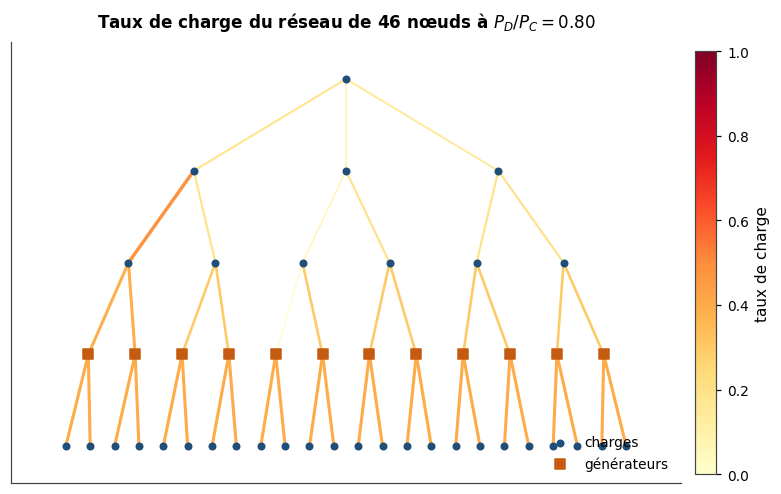

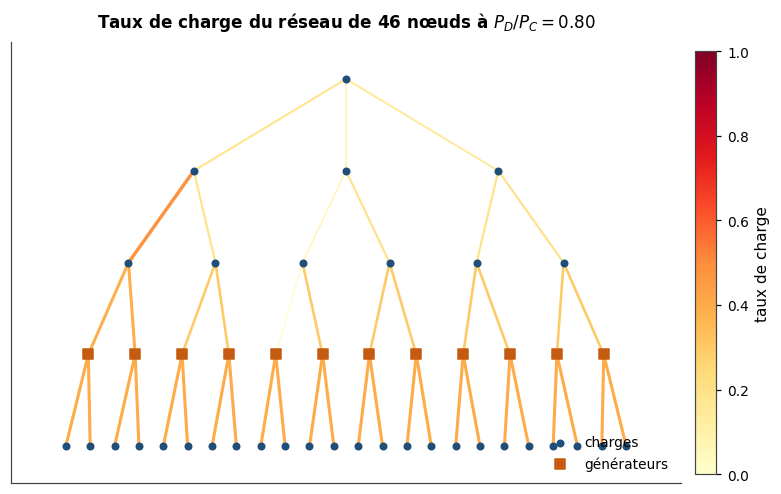

In [5]:
charge_moderee = resoudre(
    reseau,
    demande_uniforme(reseau, 0.80 * P_C),
    limites=limites,
    puissance_max=p_max,
    A=A,
)

fig = figures.reseau_en_arbre(
    reseau,
    taux=charge_moderee.taux_de_charge,
    titre=r"Taux de charge du réseau de 46 nœuds à $P_D/P_C = 0.80$",
)

figures.sauvegarder(
    fig,
    "reseau_46_apercu_charge_moderee",
    sous_dossier="02_modele_et_evolution",
)

fig

### Même structure, tailles différentes

Les réseaux de 46, 94, 190 et 382 nœuds partagent la même architecture autosimilaire : seule la profondeur de l’arbre change. Les figures suivantes montrent un état de charge modéré pour chaque taille, afin de visualiser l’augmentation progressive du réseau sans changement de structure fondamentale.

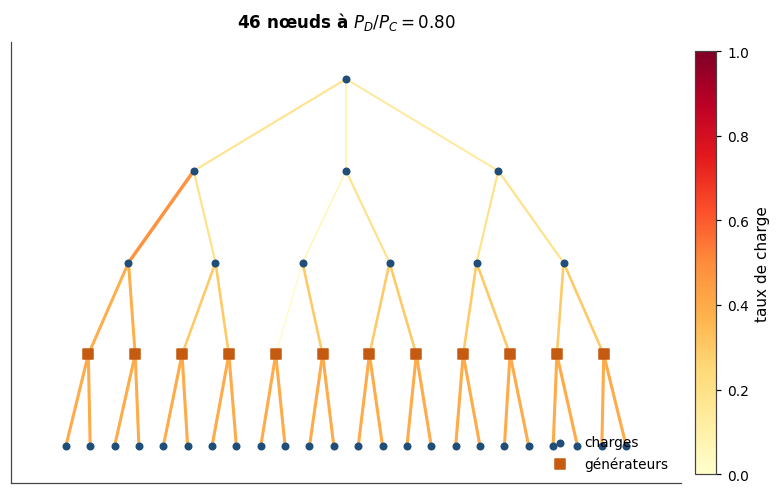

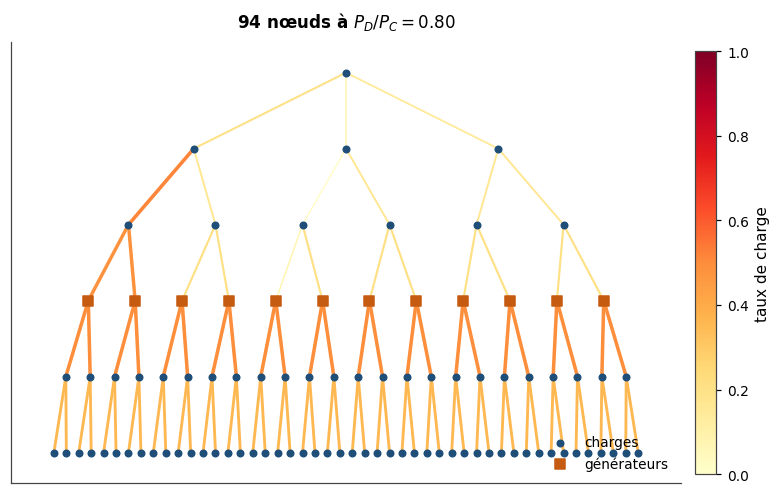

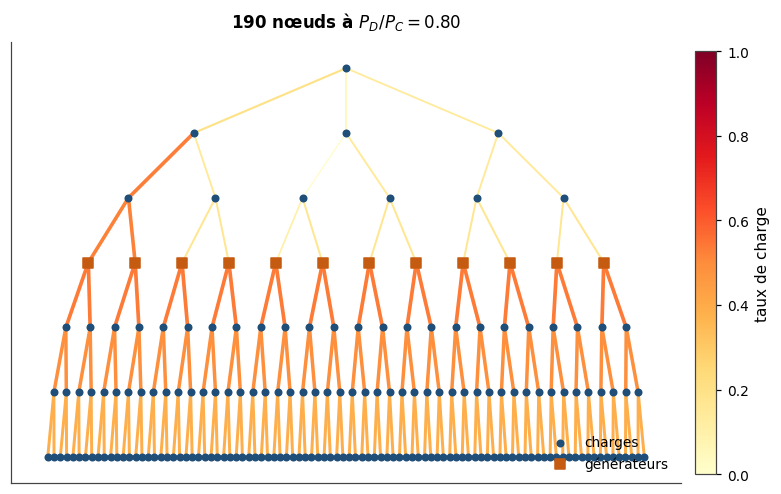

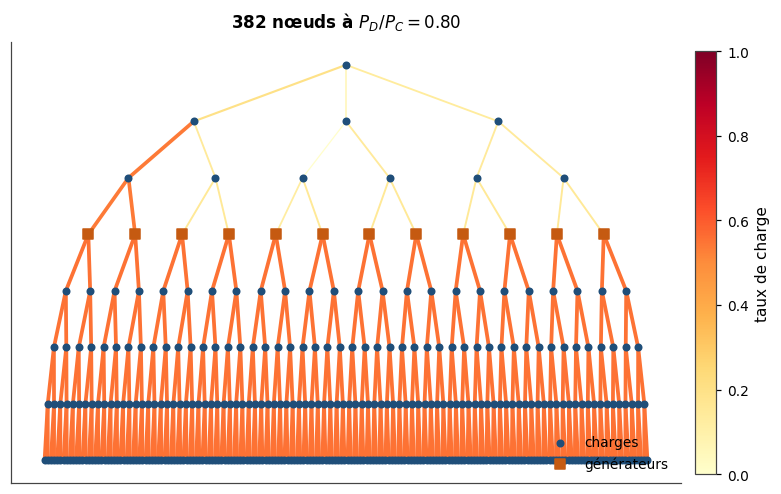

In [6]:
def figure_apercu_reseau(n_noeuds, ratio=0.80):
    cfg = configuration_arbre(n_noeuds)
    A_local = matrice_de_flux(cfg.reseau)

    sol = resoudre(
        cfg.reseau,
        demande_uniforme(cfg.reseau, ratio * cfg.p_c),
        limites=cfg.limites,
        puissance_max=cfg.puissance_max,
        A=A_local,
    )

    fig = figures.reseau_en_arbre(
        cfg.reseau,
        taux=sol.taux_de_charge,
        titre=fr"{n_noeuds} nœuds à $P_D/P_C={ratio:.2f}$",
    )
    return fig

for n in (46, 94, 190, 382):
    fig = figure_apercu_reseau(n, ratio=0.80)
    display(fig)
    plt.close(fig)

On retrouve visuellement ce que la structure analytique suggère déjà : les lignes proches de la racine portent une fraction plus importante du transport total. Cette hiérarchie jouera un rôle central lorsque les contraintes de transport commenceront à devenir actives, puis lorsque les premières cascades apparaîtront.

---

La valeur $P_L=-74$ de la Table I est conservée comme **repère de paramétrage**. Dans les balayages de charge, cependant, on ne fixe pas chaque charge à 74 : le paramètre de contrôle est le total moyen $P_D$, exprimé par

$$r=\frac{P_D}{P_C}$$

puis réparti sur les nœuds de charge. C'est ce rapport adimensionnel qui permet de comparer des réseaux de tailles différentes.

<div style="
    background: linear-gradient(135deg, #244b63 0%, #347b91 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 05 · Balayage déterministe</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Ce que prédit le modèle avant toute fluctuation</h2>
</div>


On commence par désactiver les fluctuations et les pannes. Pour chaque ratio

$$r=\frac{P_D}{P_C}$$

on répartit uniformément la demande totale $P_D=rP_C$ entre les charges et on résout le dispatch.

Deux seuils sont conceptuellement distincts :

1. **limite de génération** : $P_D=P_C$, donc $r=1$;
2. **limite de transport** : au moins une ligne atteint $M_\ell\simeq1$.

Si la génération est la seule contrainte active et $r>1$, la puissance servie ne peut dépasser P_C. On obtient alors

$$\frac{P_{\rm shed}}{P_D} = \frac{P_D-P_C}{P_D} = \boxed{\frac{r-1}{r}}$$

Cette relation cesse d'être suffisante lorsque les limites de transport deviennent elles aussi actives.

In [ ]:
RATIOS = np.linspace(0.20, 1.80, 65)

colonnes = {
    cle: [] for cle in
    ("servie", "delestage", "taux_max", "taux_moyen", "saturees", "lignes_eff")
}

for ratio in RATIOS:
    s = resoudre(
        reseau,
        demande_uniforme(reseau, ratio * P_C),
        limites=limites,
        puissance_max=p_max,
        A=A,
    )
    colonnes["servie"].append(s.charge_servie.sum() / P_C)
    colonnes["delestage"].append(s.delestage_total / (ratio * P_C))
    colonnes["taux_max"].append(s.taux_maximal)
    colonnes["taux_moyen"].append(s.taux_de_charge.mean())
    colonnes["saturees"].append(s.lignes_saturees.size)
    colonnes["lignes_eff"].append(nombre_effectif(s.flux))

balayage = {cle: np.asarray(valeurs) for cle, valeurs in colonnes.items()}

indices_transport = np.flatnonzero(balayage["taux_max"] >= 0.99)
seuil_transport = RATIOS[indices_transport[0]] if indices_transport.size else np.nan

print(f"Seuil de génération théorique : P_D/P_C = 1")
print(f"Premier ratio échantillonné avec M_max ≥ 0,99 : {seuil_transport:.3f}")

In [ ]:
seuils = {"génération": 1.0}
if np.isfinite(seuil_transport):
    seuils["transport (détecté)"] = seuil_transport

fig = figures.transitions(
    RATIOS,
    {
        "puissance servie / $P_C$": balayage["servie"],
        "fraction délestée": balayage["delestage"],
    },
    seuils,
    ylabel="puissance normalisée",
    titre="Dispatch déterministe — quantité servie et délestage",
)
figures.sauvegarder(
    fig,
    "transition_puissance_servie_table_I",
    sous_dossier="02_modele_et_evolution",
)
fig

**Comment lire cette figure.** Tant que les contraintes sont inactives, la puissance servie augmente avec la demande. Au voisinage de $r=1$, la capacité totale des générateurs devient une borne dure. Plus loin, si des lignes atteignent leur limite, le lieu où la charge peut encore être servie devient aussi important que la quantité totale disponible.

La distinction « génération » versus « transport » est importante pour les blackouts : deux scénarios peuvent avoir la même réserve globale de production, mais des vulnérabilités très différentes parce que leurs flux ne se répartissent pas de la même manière.

In [ ]:
fig = figures.transitions(
    RATIOS,
    {
        "$M_{\\max}$": balayage["taux_max"],
        "taux de charge moyen": balayage["taux_moyen"],
        "$N_{\\mathrm{eff}}/N_L$": balayage["lignes_eff"] / reseau.n_lignes,
    },
    seuils,
    ylabel="grandeur normalisée",
    titre="Structure spatiale des flux pendant le balayage",
)
figures.sauvegarder(
    fig,
    "transition_structure_flux_table_I",
    sous_dossier="02_modele_et_evolution",
)
fig

Cette seconde figure complète la première :

- M_max suit la contrainte la plus proche d'être active;
- le taux moyen dit si l'ensemble du réseau est globalement chargé;
- $N_{\rm eff}/N_L$ dit si les flux sont étalés ou concentrés.

Une montée de $M_{max}$ accompagnée d'une baisse de $N_{eff}$ correspond à une situation intuitive : **de moins en moins de lignes portent une fraction de plus en plus grande du transport**.

<div style="
    background: #442f48;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #f0b56b;
">
    <p style="color: #e6cfd7; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie III</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">De l'avarie isolée à la cascade</h2>
</div>


<div style="
    background: linear-gradient(135deg, #6b3f4f 0%, #9a5361 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f0b56b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #fbe7df; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 06 · Perturbation</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Faire tomber une ligne et redistribuer l'état</h2>
</div>


Une cascade est une suite d'états stationnaires séparés par des pannes. On ne résout donc pas une dynamique électromécanique continue : on alterne

$$
\text{dispatch}
\rightarrow
\text{panne}
\rightarrow
\text{nouveau dispatch}
\rightarrow
\text{nouvelle panne}
\rightarrow\cdots
$$

jusqu'à ce qu'aucune nouvelle ligne ne tombe.

Une ligne hors service n'est pas physiquement supprimée de la matrice. Le code multiplie sa réactance par un grand facteur $\kappa_1$ et divise sa limite par un grand facteur $\kappa_2$. Son flux devient alors pratiquement nul sans rendre le problème numérique singulier.

In [ ]:
ratio_test = 0.84
demande_test = demande_uniforme(reseau, ratio_test * P_C)

avant = resoudre(
    reseau,
    demande_test,
    limites=limites,
    puissance_max=p_max,
    A=A,
)

ligne_perdue = int(np.argmax(avant.taux_de_charge))

reseau_apres = Reseau(
    n_noeuds=reseau.n_noeuds,
    lignes=reseau.lignes,
    reactances=reseau.reactances.copy(),
    generateurs=reseau.generateurs,
    charges=reseau.charges,
    niveaux=reseau.niveaux,
    reference=reseau.reference,
)
reseau_apres.reactances[ligne_perdue] *= 1e6
limites_apres = limites.copy()
limites_apres[ligne_perdue] *= 1e-6

apres = resoudre(
    reseau_apres,
    demande_test,
    limites=limites_apres,
    puissance_max=p_max,
)

en_service = np.ones(reseau.n_lignes, dtype=bool)
en_service[ligne_perdue] = False

print(f"ligne perdue : {ligne_perdue}, nœuds {reseau.lignes[ligne_perdue]}")
print(f"délestage    : {avant.delestage_total:.3f} → {apres.delestage_total:.3f}")
print(
    f"M_max utile  : {avant.taux_maximal:.3f} → "
    f"{apres.taux_de_charge[en_service].max():.3f}"
)
print(
    f"N_eff        : {nombre_effectif(avant.flux):.2f} → "
    f"{nombre_effectif(apres.flux[en_service]):.2f}"
)

La ligne mise hors service doit être **exclue** des statistiques. Son flux et sa capacité sont tous deux quasi nuls; leur rapport peut donc avoir une valeur numérique trompeuse. `cascade.journee()` maintient explicitement un masque `hors_service` pour éviter qu'une ligne déjà tombée réapparaisse comme candidate.

Sur un arbre, une panne est particulièrement sévère parce qu'il n'existe qu'un seul chemin entre deux zones. Cela rend le système très lisible pour la validation, mais moins réaliste qu'un réseau maillé lorsque l'on étudie la redistribution.

<div style="
    background: linear-gradient(135deg, #6b3f4f 0%, #9a5361 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f0b56b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #fbe7df; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 07 · Cascade probabiliste</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Les rôles distincts de p0 et p1</h2>
</div>


La journée simulée comporte deux mécanismes de panne.

### Avarie accidentelle

Avant le premier dispatch, chaque ligne peut tomber avec probabilité $p_0$ :

$$X_\ell^{(0)}\sim \mathrm{Bernoulli}(p_0)$$

Ce mécanisme représente un **déclencheur externe** : il n'a pas besoin que la ligne soit chargée.

### Avarie par surcharge

Après un dispatch, on définit l'ensemble des lignes encore en service et proches de leur limite,

$$\mathcal S = \{\ell:\;M_\ell\ge0.99\}$$

Pour chaque $\ell\in\mathcal S$,

$$X_\ell^{(1)} \sim \mathrm{Bernoulli}(p_1)$$

Toute nouvelle panne force un redispatch; le processus recommence jusqu'à

$$\boxed{\text{aucune nouvelle panne}}$$

La taille finale du blackout est

$$P_{\rm shed} = \sum_j(d_j-L_j^{\rm final})$$

Dans la réplication contrôlée de Carreras, $p_0=10^{-4}$. Le choix $p_1=1$ est conservé comme **hypothèse explicite de réplication** : l'article utilise clairement $p_1=1$ pour les transitions déterministes, mais le paragraphe de l'expérience statistique ne redonne pas cette valeur.

<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 08 · Test d'intégration</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Un jour sans surprise</h2>
</div>


Avant une simulation longue, on vérifie la limite

$$g=p_0=p_1=0$$

Il n'y a alors ni fluctuation ni panne. Toute la chaîne

$$\texttt{evolution} \rightarrow \texttt{cascade} \rightarrow \texttt{dispatch}$$

doit se réduire au dispatch stationnaire direct.

In [ ]:
DEMANDE_CONTROLE = 0.84 * P_C

parametres_nuls = evolution.Parametres(
    mode="independant",
    demande_initiale=DEMANDE_CONTROLE,
    puissance_max=p_max,
    g=0.0,
    p0=0.0,
    p1=0.0,
    limites=limites,
)

rng_nul = np.random.default_rng(GRAINE)
un_jour = evolution.simuler(reseau, 1, parametres_nuls, rng_nul)[0]

solution_directe = resoudre(
    reseau,
    demande_uniforme(reseau, DEMANDE_CONTROLE),
    limites=limites,
    puissance_max=p_max,
)

print(f"délestage (chaîne complète) : {un_jour.delestage_total:.9f}")
print(f"délestage (dispatch direct) : {solution_directe.delestage_total:.9f}")
print(f"M_max (chaîne complète)     : {un_jour.taux_maximal:.9f}")
print(f"M_max (dispatch direct)     : {solution_directe.taux_maximal:.9f}")

assert np.isclose(un_jour.delestage_total, solution_directe.delestage_total)
assert np.isclose(un_jour.taux_maximal, solution_directe.taux_maximal)
print("✓ cohérence stationnaire vérifiée")

Ce test ne démontre pas que la physique du modèle est parfaite. Il démontre quelque chose de plus ciblé : **les couches ajoutées autour du dispatch ne modifient pas l'état lorsqu'elles sont désactivées**. C'est exactement le type de propriété que l'on veut verrouiller avant d'analyser des résultats complexes.

<div style="
    background: #173a52;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #e7a23b;
">
    <p style="color: #c7dce8; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie IV</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">De la journée aux séries temporelles</h2>
</div>


<div style="
    background: linear-gradient(135deg, #244b63 0%, #347b91 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 09 · Deux protocoles</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Monte-Carlo i.i.d. versus dynamique avec mémoire</h2>
</div>


`evolution.simuler()` produit une observation par journée, mais deux usages doivent être distingués.

### Mode `independant`

Le réseau est remis dans le même état au début de chaque réalisation. Si

$$Y_t$$

désigne une observable quotidienne, alors les $Y_t$ sont conçus comme des tirages d'une même expérience :

$$Y_t\overset{\mathrm{i.i.d.}}{\sim}\mathcal D$$

L'indice $t$ sert seulement à ranger les réalisations.

### Mode `auto_organise`

L'état du jour $t+1$ dépend du jour $t$. Trois rétroactions lentes sont ajoutées.

La croissance annuelle $\lambda_{\rm an}$ est convertie en facteur quotidien

$$\lambda_d=\lambda_{\rm an}^{1/365}$$

puis le code utilise

$$\bar P_D(t) = P_D(0)\exp[(\lambda_d-1)t]$$

Pour $\lambda_{\rm an}$ proche de 1, cette écriture est pratiquement équivalente à $P_D(0)\lambda_{\rm an}^{t/365}$.

La marge moyenne de génération est

$$m(t) = \frac{\sum_jP_j^{\max}(t)-\bar P_D(t)}{\bar P_D(t)}$$

Si $m(t)<m_c$, une mise à niveau d'un générateur ajoute

$$\Delta P_j^{\max} = k\frac{\bar P_D(t)}{N_G}$$

Après un blackout, une ligne tombée **par surcharge** est renforcée selon

$$F_\ell^{\max}(t+1) = \mu F_\ell^{\max}(t), \qquad \mu\ge1$$

C'est cette dépendance de l'état futur envers les événements passés qui crée la mémoire du système.

<div style="background:#edf5f8;color:#1f2933;border-left:4px solid #347b91;padding:12px 16px;border-radius:7px;">
<strong>Important.</strong> Les cellules de cette partie servent à valider le
mécanisme temporel et à produire les séries du fil B. Elles ne constituent pas
la réplication statistique de Carreras (2002), qui utilise des fluctuations
<strong>régionales</strong> et sera traitée séparément dans la Partie V.
</div>


In [ ]:
# Contrôle temporel : réseau fixe, fluctuations indépendantes par charge.
N_JOURS_INDEP = 2000

parametres_indep = evolution.Parametres(
    mode="independant",
    demande_initiale=0.84 * P_C,
    puissance_max=p_max,
    g=0.9,               # convention interne : [1-g, 1+g]
    p0=P0_TABLE,
    p1=P1_REFERENCE,
    limites=limites,
)

rng_indep = np.random.default_rng(GRAINE)
jours_indep = evolution.simuler(reseau, N_JOURS_INDEP, parametres_indep, rng_indep)
series_indep = evolution.series(jours_indep)

print(f"{N_JOURS_INDEP} réalisations i.i.d.")
print(f"jours avec délestage : {(series_indep['delestage_total'] > 1e-9).mean():.2%}")
print(f"M_max moyen          : {series_indep['taux_maximal'].mean():.3f}")
print(f"N_eff moyen          : {np.nanmean(series_indep['nombre_effectif']):.2f}")

In [ ]:
fig = figures.galerie_series(
    {
        "délestage": series_indep["delestage_total"],
        "$M_{max}$": series_indep["taux_maximal"],
        "$N_{eff}$": series_indep["nombre_effectif"],
    },
    n_points=250,
    titre="Contrôle i.i.d. — premiers 250 tirages",
)
figures.sauvegarder(
    fig,
    "apercu_independant_table_I",
    sous_dossier="02_modele_et_evolution",
)
fig

**Comment lire cette figure.** Les points consécutifs n'ont pas de causalité temporelle : un pic au tirage $t$ ne modifie pas le réseau au tirage $t+1$. La figure sert donc de contrôle pour le fil B : une mesure qui prétend détecter une mémoire lente devrait rester prudente sur ce type de données.

<div style="
    background: linear-gradient(135deg, #244b63 0%, #347b91 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 10 · Rétroaction lente</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Démonstrateur auto-organisé à échelle réduite</h2>
</div>


Pour rendre le mécanisme visible sans lancer immédiatement $10^5$ journées, on utilise un démonstrateur de 3000 jours. Les paramètres ci-dessous servent à tester **la logique de rétroaction**, pas à établir une criticalité auto-organisée asymptotique.

In [ ]:
N_JOURS_AUTO = 3000
DEMANDE_AUTO_INITIALE = 0.70 * P_C

MARGE_INITIALE = 0.16
MARGE_SEUIL = 0.08
MU = 1.05
K = 0.02
LAMBDA_ = 1.018

puissance_auto = evolution.puissance_max_pour_marge(
    reseau,
    DEMANDE_AUTO_INITIALE,
    MARGE_INITIALE,
)

parametres_auto = evolution.Parametres(
    mode="auto_organise",
    demande_initiale=DEMANDE_AUTO_INITIALE,
    puissance_max=puissance_auto,
    g=0.9,
    p0=P0_TABLE,
    p1=P1_REFERENCE,
    limites=limites,
    lambda_=LAMBDA_,
    k=K,
    marge_seuil=MARGE_SEUIL,
    mu=MU,
)

rng_auto = np.random.default_rng(GRAINE)
jours_auto = evolution.simuler(reseau, N_JOURS_AUTO, parametres_auto, rng_auto)
series_auto = evolution.series(jours_auto)

print(f"marge initiale : {series_auto['marge_moyenne'][0]:.2%}")
print(f"marge finale   : {series_auto['marge_moyenne'][-1]:.2%}")
print(
    f"capacité totale : {series_auto['capacite_totale_generateurs'][0]:.1f} "
    f"→ {series_auto['capacite_totale_generateurs'][-1]:.1f}"
)
print(f"mises à niveau cumulées : {int(series_auto['n_mises_a_niveau'].sum())}")
print(f"lignes renforcées       : {int(series_auto['n_lignes_renforcees'].sum())}")

In [ ]:
fig = figures.galerie_series(
    {
        "capacité": series_auto["capacite_totale_generateurs"],
        "marge": series_auto["marge_moyenne"],
        "délestage": series_auto["delestage_total"],
    },
    n_points=N_JOURS_AUTO,
    titre="Démonstrateur auto-organisé — 3000 jours",
)
figures.sauvegarder(
    fig,
    "apercu_auto_organise_table_I",
    sous_dossier="02_modele_et_evolution",
)
fig

**Interprétation simple.** La demande moyenne dérive lentement vers le haut. Lorsque la marge devient trop petite, le modèle ajoute de la capacité; lorsqu'une ligne tombe par surcharge lors d'un blackout, cette ligne peut être renforcée. Le système réagit donc à son propre historique.

Ce que cette expérience établit :

$$\text{croissance} \rightarrow \text{perte de marge} \rightarrow \text{réponse d'ingénierie} \rightarrow \text{nouvel état}$$

Ce qu'elle **n'établit pas** : une loi d'échelle, un régime stationnaire asymptotique ou une criticalité auto-organisée. Ces affirmations exigent des simulations beaucoup plus longues et une analyse statistique dédiée.

<div style="
    background: linear-gradient(135deg, #8b5e34 0%, #b47a3c 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f1c36b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #fff1d4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 11 · Interface avec le fil B</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Comparer puis exporter les séries</h2>
</div>


In [ ]:
fig = figures.distributions_comparees(
    {
        "independant": series_indep["nombre_effectif"],
        "auto_organise": series_auto["nombre_effectif"],
    },
    xlabel="nombre effectif de lignes",
    titre="Répartition spatiale des flux — deux protocoles temporels",
)
figures.sauvegarder(
    fig,
    "comparaison_nombre_effectif_table_I",
    sous_dossier="02_modele_et_evolution",
)
fig

Cette comparaison est descriptive, pas causale : les deux protocoles diffèrent par plusieurs mécanismes à la fois. Son intérêt principal est méthodologique : elle fournit au fil B une série sans mémoire imposée et une série avec rétroaction lente.

On sauvegarde donc ces séries séparément de l'expérience Carreras contrôlée.

In [ ]:
chemin_indep = DOSSIER_DATA / "evolution_independant.npz"
chemin_auto = DOSSIER_DATA / "evolution_auto_organise.npz"

evolution.ecrire(series_indep, chemin_indep)
evolution.ecrire(series_auto, chemin_auto)

print(f"écrit : {chemin_indep}")
print(f"écrit : {chemin_auto}")

<div style="
    background: #2b4a3f;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #e7a23b;
">
    <p style="color: #d9eee6; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie V</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Validation du modèle : réplication contrôlée de Carreras</h2>
</div>


<div style="
    background: linear-gradient(135deg, #2f5d50 0%, #3f7a68 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 12 · Audit du protocole</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Pourquoi une réplication séparée était nécessaire</h2>
</div>


La première recherche de loi de puissance a joué un rôle utile : elle a montré qu'une grande simulation ne compense pas un protocole mal contrôlé. Trois points ont alors été corrigés.

$$\boxed{P_G=2623.9\;\text{par générateur}} \quad\Longrightarrow\quad \boxed{P_C=31486.8}$$

Les limites sont maintenant celles de la Table I, sans recalibration par taille, et les fluctuations de demande sont corrélées par régions comme dans la section V de Carreras et al. (2002).

Le protocole publié fournit explicitement :

$$\gamma=1.9,\qquad p_0=10^{-4}$$

un balayage de $P_D/P_C$, des fluctuations régionales et $60\,000$ réalisations par jeu de paramètres.

Deux éléments restent des hypothèses documentées de notre réplication :

- $N_F=3$, choisi comme les trois branches principales de l'arbre;
- $p_1=1$, cohérent avec les transitions étudiées dans le papier mais non
  redonné explicitement dans le paragraphe de l'expérience statistique.

L'objectif n'est donc pas de masquer les incertitudes, mais de les rendre explicites et testables.

<div style="
    background: linear-gradient(135deg, #2f5d50 0%, #3f7a68 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 13 · Fluctuations régionales</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Garder la même intensité de bruit quand le réseau grandit</h2>
</div>


Carreras n'impose pas nécessairement un facteur indépendant à chaque charge. Les charges sont regroupées en régions. Si $R(i)$ désigne la région de la charge $i$,

$$d_i=\bar d_i\,r_{R(i)}$$

Toutes les charges d'une même région partagent donc le même facteur.

Les bornes publiées sont

$$2-\gamma\le r_f\le\gamma$$

Avec $\gamma=1.9$,

$$0.1\le r_f\le1.9$$

Le papier donne pour l'écart-type de la demande totale

$$\boxed{\sigma_{\rm papier} = \frac{\gamma-1}{2\sqrt{N_F}}\,P_D}$$

La densité exacte des $r_f$ n'est toutefois pas donnée dans le passage disponible. Notre implémentation choisit explicitement

$$r_f\sim\mathcal U(2-\gamma,\gamma)$$

Sous cette hypothèse uniforme,

$$\operatorname{Var}(r_f)=\frac{(\gamma-1)^2}{3}$$

Si la région $f$ porte une fraction $w_f$ de la charge totale,

$$\frac{\sigma_{\rm uniforme}}{P_D} = \frac{\gamma-1}{\sqrt 3} \sqrt{\sum_f w_f^2}$$

Pour des régions égales, $w_f=1/N_F$,

$$\frac{\sigma_{\rm uniforme}}{P_D} = \frac{\gamma-1}{\sqrt{3N_F}}$$

Cette différence de coefficient avec la formule du papier est documentée : nous reproduisons les bornes et la corrélation régionale, mais la loi uniforme demeure une hypothèse de réplication.

In [ ]:
audit_regions = []
for n_noeuds in (46, 94):
    cfg = configuration_arbre(n_noeuds)
    groupes = groupes_regions(cfg.reseau, n_regions=3)
    comptes = np.bincount(groupes, minlength=3)

    audit_regions.append({
        "nœuds": n_noeuds,
        "charges par région": tuple(comptes.tolist()),
        "σ/P_D — hypothèse uniforme": sigma_relatif_uniforme(groupes, GAMMA_TABLE),
        "σ/P_D — formule du papier": sigma_relatif_papier(3, GAMMA_TABLE),
    })

display(pd.DataFrame(audit_regions))


Le point méthodologique essentiel est que les poids des trois régions restent pratiquement identiques quand on passe de 46 à 94 nœuds. L'amplitude relative des fluctuations globales ne s'effondre donc plus comme $1/\sqrt{N_L}$, ce qui arrivait lorsque chaque charge fluctuait indépendamment.

Autrement dit, on peut enfin augmenter $N$ **sans changer involontairement la force du bruit**.

<div style="
    background: linear-gradient(135deg, #2f5d50 0%, #3f7a68 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 14 · Scan exploratoire</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Choisir le ratio commun avant la production longue</h2>
</div>


Le scan utilise le **même** ratio $r=P_D/P_C$ pour les deux tailles. À chaque ratio, on calcule trois diagnostics.

### 1. Fréquence de blackout

$$f_B(r) = \frac{1}{N_{\rm sim}} \sum_{k=1}^{N_{\rm sim}} \mathbf 1\!\left(P_{\rm shed}^{(k)}>0\right)$$

### 2. Distance de Kolmogorov–Smirnov de la queue

Pour une loi de puissance ajustée au-dessus de $x_{\min}$,

$$D_{\rm KS} = \sup_{x\ge x_{\min}} \left| F_{\rm emp}(x)-F_{\rm PL}(x) \right|$$

Plus $D_{\rm KS}$ est petit, plus l'ajustement est proche de la CDF empirique.

### 3. Étendue de la queue

$$\boxed{\Delta = \log_{10}\!\left(\frac{x_{\max}}{x_{\min}}\right)}$$

Une décade correspond à un facteur 10 en amplitude.

Le ratio de production n'est **pas** choisi parce qu'il donne le plus grand $\Delta$, ce qui favoriserait artificiellement l'effet recherché. Le critère est fixé avant le run confirmatoire :

$$\boxed{r^\star = \arg\min_r \max\left[D_{46}(r),D_{94}(r)\right]}$$

avec au moins 100 observations dans la queue pour chaque taille.

In [ ]:
scan_path = DATA_REP / "scan.csv"

if scan_path.exists():
    scan = pd.read_csv(scan_path)

    candidats = []
    for ratio in sorted(scan["ratio_PD_PC"].unique()):
        sous = scan[np.isclose(scan["ratio_PD_PC"], ratio)]
        if len(sous) != 2:
            continue
        if not np.all(sous["shed_n_tail"].to_numpy() >= 100):
            continue
        if not np.all(np.isfinite(sous["shed_D"].to_numpy())):
            continue

        candidats.append({
            "P_D/P_C": ratio,
            "pire KS": sous["shed_D"].max(),
            "Δ minimal": sous["shed_tail_decades"].min(),
            "blackout min": sous["freq_blackout"].min(),
            "blackout max": sous["freq_blackout"].max(),
        })

    candidats = (
        pd.DataFrame(candidats)
        .sort_values(["pire KS", "Δ minimal"], ascending=[True, False])
        .reset_index(drop=True)
    )
    display(candidats.head(8))

    ratio_commun = float(candidats.iloc[0]["P_D/P_C"])
    print(f"ratio commun retenu par le critère : {ratio_commun:.3f}")
else:
    print("scan.csv absent — lancer scripts/05_reproduction_carreras.py scan")

### Figure — scan contrôlé

![Scan contrôlé de la fréquence de blackout, de la distance KS et de l'étendue de queue](../figures/05_reproduction_carreras/05_scan_controle.png)

**Panneau supérieur — fréquence de blackout.**  
Il répond à « combien de réalisations produisent un délestage ? ». Les courbes 46 et 94 nœuds restent proches, ce qui indique que les deux tailles explorent des régimes de stress comparables.

**Panneau central — distance KS.**  
Ici, **plus bas est meilleur**. Le creux commun autour de $P_D/P_C=0.84$ signifie que ce ratio donne le meilleur compromis pour ajuster simultanément les deux queues.

**Panneau inférieur — étendue $\Delta$.**  
Ici, **plus haut signifie une plage de queue plus longue**, mais une grande $\Delta$ n'est pas une preuve de loi de puissance. Une longue région fortement courbée peut avoir un mauvais $D_{\rm KS}$.

Le critère pré-enregistré retient

$$\boxed{\frac{P_D}{P_C}=0.84}$$

Le choix ne dépend donc pas du résultat de la simulation confirmatoire qui suit.

<div style="
    background: linear-gradient(135deg, #2f5d50 0%, #3f7a68 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 15 · Production confirmatoire</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">60 000 réalisations par taille à P_D/P_C = 0.84</h2>
</div>


La taille principale d'un blackout est normalisée par la demande moyenne contrôlée de l'expérience,

$$\bar P_D=rP_C$$

de sorte que

$$X = \frac{P_{\rm shed}}{\bar P_D}$$

On étudie sa fonction de survie

$$\bar F(x) = P(X\ge x)$$

Si la densité suit une loi de puissance

$$p(x)\propto x^{-\alpha}$$

alors la fonction de survie suit

$$\bar F(x)\propto x^{-(\alpha-1)}$$

Une loi de puissance idéale apparaît donc comme une droite dans un graphique log-log. Une courbure vers le bas indique au contraire une coupure ou une autre famille de distribution.

L'ajustement fournit $x_{\min}$, $\alpha$ et $D_{\rm KS}$, puis compare la log-vraisemblance de la loi de puissance à des alternatives. Pour une alternative $A$,

$$R_{\rm PL/A} = \ell_{\rm PL}-\ell_A$$

Ainsi :

$$R>0 \Rightarrow \text{loi de puissance favorisée}, \qquad R<0 \Rightarrow \text{alternative favorisée}$$

In [ ]:
resume_path = DATA_REP / "resume_production.csv"

if resume_path.exists():
    production = pd.read_csv(resume_path)

    colonnes = [
        "n_noeuds",
        "ratio_PD_PC",
        "n_realisations",
        "freq_blackout",
        "freq_lignes_tombees",
        "shed_alpha",
        "shed_xmin",
        "shed_D",
        "shed_n_tail",
        "shed_tail_decades",
        "shed_R_lognormale",
        "shed_p_lognormale",
        "lignes_tombees_max",
        "facteur_demande_sigma",
    ]
    display(production[colonnes])
else:
    print(
        "resume_production.csv absent — lancer : "
        "python scripts/05_reproduction_carreras.py production "
        "--ratio 0.84 --n 60000 --workers 16 --chunk-size 2500"
    )

### Figure — queue des tailles de blackout

![CCDF des tailles de blackout pour les arbres de 46 et 94 nœuds](../figures/05_reproduction_carreras/05_ccdf_taille_finie.png)

Les deux courbes empiriques se prolongent sur plusieurs ordres de probabilité, mais elles se **courbent vers le bas** aux grandes tailles au lieu de suivre indéfiniment la droite ajustée.

Pour la campagne confirmatoire actuelle :

$$
\begin{array}{c|cc}
&46\text{ nœuds}&94\text{ nœuds}\\
\hline
f_B & 27.67\% & 29.66\%\\
D_{\rm KS} & 0.1307 & 0.1207\\
n_{\rm tail} & 7184 & 8000\\
\Delta & 0.583 & 0.820\\
\alpha & 2.9997 & 2.7645
\end{array}
$$

La signature directionnelle recherchée survit donc au run indépendant :

$$\boxed{\Delta_{94}>\Delta_{46}}$$

Mais les rapports de vraisemblance donnent environ

$$R_{\rm PL/LN}^{46}=-968, \qquad R_{\rm PL/LN}^{94}=-937$$

avec des $p$-values extrêmement petites. La lognormale est donc très fortement préférée à la loi de puissance dans les queues ajustées.

<div style="background:#fff6e8;color:#1f2933;border-left:5px solid #e7a23b;padding:14px 18px;border-radius:8px;">
<strong>Conclusion correcte.</strong>
On observe une <strong>signature de taille finie</strong> — la queue s'étend davantage quand le réseau grandit — mais on ne peut pas écrire « loi de puissance confirmée ». Les valeurs de α sont les paramètres du meilleur ajustement power-law disponible, pas encore des exposants physiques validés.
</div>

<div style="
    background: linear-gradient(135deg, #2f5d50 0%, #3f7a68 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 16 · Structure des cascades</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Ce qui change vraiment entre 46 et 94 nœuds</h2>
</div>


In [ ]:
def charger_npz(n_noeuds):
    chemin = DATA_REP / f"production_{n_noeuds}_noeuds.npz"
    return np.load(chemin) if chemin.exists() else None

brut46 = charger_npz(46)
brut94 = charger_npz(94)

def resume_cascades(brut, n_noeuds):
    n_lignes = brut["n_lignes_tombees"]
    positives = n_lignes[n_lignes > 0]

    return {
        "nœuds": n_noeuds,
        "réalisations": n_lignes.size,
        "avec ≥1 ligne tombée": int((n_lignes > 0).sum()),
        "fréquence ≥1 ligne": float((n_lignes > 0).mean()),
        "cascades >1 ligne": int((n_lignes > 1).sum()),
        "P(>1 | ≥1)": float((positives > 1).mean()) if positives.size else np.nan,
        "max lignes tombées": int(n_lignes.max()),
        "moyenne | ≥1": float(positives.mean()) if positives.size else np.nan,
    }

if brut46 is not None and brut94 is not None:
    stats_cascades = pd.DataFrame([
        resume_cascades(brut46, 46),
        resume_cascades(brut94, 94),
    ])
    display(stats_cascades)
else:
    print("Fichiers production_46_noeuds.npz / production_94_noeuds.npz absents.")

In [ ]:
if brut46 is not None and brut94 is not None:
    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for n_noeuds, brut in ((46, brut46), (94, brut94)):
        valeurs = brut["n_lignes_tombees"]
        valeurs = valeurs[valeurs > 0]
        x, compte = np.unique(valeurs, return_counts=True)
        ax.plot(x, compte / compte.sum(), marker="o", label=f"{n_noeuds} nœuds")

    ax.set_yscale("log")
    ax.set_xlabel("nombre de lignes tombées dans la réalisation")
    ax.set_ylabel("probabilité conditionnelle à au moins une panne de ligne")
    ax.set_title("Émergence des cascades multi-lignes")
    ax.grid(alpha=0.25, which="both")
    ax.legend()
    fig.tight_layout()

    chemin = FIG_REP / "05_distribution_lignes_tombees.png"
    chemin.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(chemin, dpi=180)
    plt.show()
    print(f"figure sauvegardée : {chemin}")

La différence physique est beaucoup plus nette ici que dans un simple coefficient d'ajustement.

Dans les $60\,000$ réalisations actuelles :

- **46 nœuds** : 345 réalisations ont une panne de ligne, et elles n'impliquent
  qu'une seule ligne;
- **94 nœuds** : 2245 réalisations ont une panne de ligne, environ $64.5\%$
  de ces événements en font tomber plus d'une, et le maximum observé atteint 17.

Autrement dit, le passage $46\rightarrow94$ ne fait pas seulement « étirer une courbe ». Il fait apparaître des **cascades multi-lignes** qui n'existent pas dans l'échantillon 46 nœuds.

Pour le 94 nœuds, le délestage nominal moyen vaut environ $0.048$ lorsqu'aucune ligne ne tombe, contre environ $0.355$ lorsqu'au moins une ligne tombe. Les événements de ligne alimentent donc préférentiellement la partie sévère de la distribution.

<div style="
    background: linear-gradient(135deg, #2f5d50 0%, #3f7a68 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 17 · Normalisation</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Pourquoi P_shed / P_D peut d?passer 1</h2>
</div>


La figure principale normalise par la demande moyenne contrôlée

$$\bar P_D=rP_C$$

et non par la demande réellement tirée lors d'une réalisation. Or les facteurs régionaux peuvent produire

$$P_D^{\rm réel}>\bar P_D$$

Il est donc possible d'observer

$$\frac{P_{\rm shed}}{\bar P_D}>1$$

sans jamais délester plus que la demande réellement présente.

La vérification physique est

$$0 \le \frac{P_{\rm shed}}{P_D^{\rm réel}}\le1$$

Conserver les deux normalisations est utile :

$$\frac{P_{\rm shed}}{\bar P_D} \quad\text{compare les réalisations à un même niveau expérimental,}$$

alors que

$$\frac{P_{\rm shed}}{P_D^{\rm réel}} \quad\text{mesure la fraction effectivement perdue ce jour-là.}$$

In [ ]:
if brut46 is not None and brut94 is not None:
    controle_norm = []
    for n_noeuds, brut in ((46, brut46), (94, brut94)):
        controle_norm.append({
            "nœuds": n_noeuds,
            "max P_D réel / P_D moyen": float(brut["facteur_demande_totale"].max()),
            "max P_shed / P_D moyen": float(brut["fraction_delestee_nominale"].max()),
            "max P_shed / P_D réel": float(brut["fraction_delestee_realisee"].max()),
        })
    display(pd.DataFrame(controle_norm))

Le contrôle doit toujours confirmer

$$\max\left(\frac{P_{\rm shed}}{P_D^{\rm réel}}\right)\le1$$

Dans la campagne actuelle, c'est bien le cas. Le dépassement de 1 sur l'axe nominal du 94 nœuds est donc un effet de normalisation, pas une violation de la conservation de la puissance.

<div style="
    background: #5a4432;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #f1c36b;
">
    <p style="color: #f2dfc7; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie VI</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Ce que la réplication établit — et ce qu'elle ne prouve pas</h2>
</div>


| Question | État actuel | Interprétation |
|---|---|---|
| Les deux tailles voient-elles une intensité de fluctuation comparable ? | **Oui** | $\sigma/\bar P_D\simeq0.30145$ pour les deux tailles |
| Les fréquences de blackout sont-elles comparables à $r=0.84$ ? | **Oui** | environ 28–30 % |
| La région ajustée s'élargit-elle de 46 à 94 nœuds ? | **Oui** | $\Delta:0.583\rightarrow0.820$ |
| Des cascades multi-lignes apparaissent-elles avec la taille ? | **Oui** | absentes dans le 46 observé; présentes jusqu'à 17 lignes dans le 94 |
| La loi de puissance est-elle statistiquement préférée ? | **Non** | la lognormale est très fortement favorisée |
| Peut-on parler de finite-size scaling complet ? | **Pas encore** | deux tailles donnent une direction, pas une loi d'échelle |
| Peut-on parler de criticalité auto-organisée ? | **Non** | l'expérience actuelle est un réseau fixe, pas la dynamique lente stationnaire |

Le résultat le plus important n'est donc pas « nous avons trouvé une loi de puissance ». C'est plutôt :

$$\boxed{\text{un protocole corrigé fait apparaître une croissance reproductible de l'étendue des cascades avec la taille du réseau}}$$

tout en montrant clairement que la forme statistique complète de Carreras n'est pas encore reproduite.

<div style="
    background: linear-gradient(135deg, #6c5139 0%, #8b6a48 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f1c36b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #fff1d4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 18 · Étape suivante</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Tester 46 → 94 → 190 → 382 sans changer le protocole</h2>
</div>


La prochaine expérience naturelle conserve

$$P_G,\;F_\ell^{\max},\;\gamma,\;p_0,\;p_1,\;N_F$$

la règle de partition régionale, le ratio commun $P_D/P_C$ et le pipeline statistique. Seule la taille change :

$$\boxed{46\rightarrow94\rightarrow190\rightarrow382}$$

La première signature recherchée est

$$\Delta_{46} < \Delta_{94} < \Delta_{190} < \Delta_{382}$$

Mais, pour éviter de faire reposer la conclusion sur un ajustement de loi de puissance qui est actuellement défavorisé, il faudra suivre **en parallèle** :

$$N_{\rm outages}^{\max}, \qquad Q_{0.95}(N_{\rm outages}), \qquad Q_{0.99}(P_{\rm shed})$$

ainsi que

$$R_{\rm PL/LN}$$

Une vraie reproduction de la queue algébrique demanderait en plus un test absolu de goodness-of-fit (par exemple bootstrap du KS) plutôt qu'une simple comparaison relative entre distributions.

Commandes prévues :

```powershell
python scripts/05_reproduction_carreras.py scan --tailles 46 94 190 382 --workers 16
```

puis, une fois le ratio commun figé,

```powershell
python scripts/05_reproduction_carreras.py production --tailles 46 94 190 382 --ratio <RATIO> --n 60000 --workers 16 --chunk-size 2500
```

Le principe expérimental est volontairement strict : **ne pas retoucher le modèle pour améliorer une courbe après avoir vu le résultat**.

<div style="
    background: #102a43;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #e7a23b;
">
    <p style="color: #dcefeb; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie VII</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Passage du fil A au fil B</h2>
</div>


Le fil A produit désormais deux familles de données distinctes :

1. `evolution_independant.npz` et `evolution_auto_organise.npz` pour comparer
   absence et présence de mémoire temporelle;
2. `data/05_reproduction_carreras/` pour la validation statistique du modèle
   de cascade à réseau fixe.

Le notebook 03 peut donc commencer à partir de séries déjà construites, sans mélanger le développement du modèle électrique et l'analyse informationnelle.

Les observables principales restent

$$P_{\rm shed}(t), \qquad M_{\max}(t), \qquad N_{\rm eff}(t)$$

auxquelles s'ajoutent, pour la réplication Carreras,

$$N_{\rm outages}, \qquad \frac{P_{\rm shed}}{\bar P_D}, \qquad \frac{P_{\rm shed}}{P_D^{\rm réel}}$$

Cette séparation est méthodologiquement importante : le fil B doit tester des mesures d'information sur des données dont la provenance et les hypothèses ont déjà été documentées ici.

<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 100%);
    padding: 22px 26px;
    border-radius: 10px;
    margin: 34px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(16,42,67,0.22);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Bilan · Fil A</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Une chaîne comprise, testée et encore falsifiable</h2>
</div>

Le notebook établit désormais une progression cohérente :

$$\text{équations} \rightarrow \text{cas analytique} \rightarrow \text{dispatch} \rightarrow \text{cascade} \rightarrow \text{mémoire lente} \rightarrow \text{réplication contrôlée}$$

**Ce qui est solide :** la cohérence du dispatch, la séparation des mécanismes $p_0/p_1$, la correction de P_C, l'utilisation des limites de la Table I, l'appariement de l'intensité des fluctuations entre 46 et 94 nœuds et l'apparition reproductible de cascades plus étendues sur le réseau plus grand.

**Ce qui reste ouvert :** la loi exacte de fluctuation régionale correspondant à la formule de variance du papier, la valeur de $N_F$ utilisée par les auteurs, la forme asymptotique de la queue, la dégénérescence du dispatch dans certaines bandes erratiques, l'extension 190/382 et la validation sur un réseau maillé.

<div style="text-align:center;color:#52656d;font-size:12px;margin-top:16px;">
<strong>Le fil A n'a pas à produire le résultat espéré.</strong>
Il doit rendre clair ce qui est imposé, ce qui émerge et ce qui échoue. C'est sur cette base que le fil B peut chercher une information réellement nouvelle.
</div>

## Références méthodologiques principales

**Carreras, B. A., Lynch, V. E., Dobson, I. & Newman, D. E. (2002).**  
*Critical points and transitions in an electric power transmission model for cascading failure blackouts.*  
Chaos **12**(4), 985–994.

**Carreras, B. A., Newman, D. E., Dobson, I. & Poole, A. B. (2004).**  
*Evidence for self-organized criticality in a time series of electric power system blackouts.*  
Référence utilisée pour la dynamique lente, les marges et les renforcements.

**Clauset, A., Shalizi, C. R. & Newman, M. E. J. (2009).**  
*Power-Law Distributions in Empirical Data.* SIAM Review **51**(4), 661–703.  
Référence méthodologique pour l'estimation de $x_{\min}$, de $\alpha$ et la
comparaison de la loi de puissance à des distributions alternatives.

---

### Convention documentaire du projet

Les équations ci-dessus décrivent soit les équations publiées, soit
l'implémentation effective du dépôt. Lorsqu'une valeur n'est pas donnée
explicitement par l'article — notamment $N_F$, la densité exacte des facteurs
régionaux et le $p_1$ de l'expérience de la section V — elle est identifiée
comme **hypothèse de réplication**, jamais comme donnée publiée.
